# Part 3: Filtering and the marginal log-likelihood

This notebook is part of the [Gentle Introduction to Dynestyx](00_index.ipynb). We use **filtering** (e.g. the cuthbert particle filter) to compute the **marginal log-likelihood** (MLL) $\log p(y_{1:T} \mid \theta)$ at fixed parameters $\theta$, and show how to switch to a different filter (e.g. Taylor KF).

## 3.1 Why filtering? Computing MLL without sampling states

Sometimes we don't want to sample the full state trajectory—we only care about **parameters** $\theta$. The **marginal log-likelihood** is $\log p(y_{1:T} \mid \theta)$ with states integrated out. Dynestyx provides **filtering** handlers that add this MLL as a NumPyro factor, so we can evaluate $\log p(\text{data} \mid \theta)$ at any $\theta$.

We'll use the **particle filter** (cuthbert PF) to compute a "profile likelihood": that is, we will plot the MLL vs $\theta$.

We evaluate the model at fixed parameters (as when using `Predictive` with `params=...`) and read the MLL factor from the trace.

### Define the model

In [1]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive
import jax.random as jr
import jax.numpy as jnp
import dynestyx as dsx
from dynestyx import DynamicalModel, Condition, DiscreteTimeSimulator, Context, Trajectory

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))


def lti_model(sigma_obs=0.1, sigma_process=0.1):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5))
    A = jnp.array([[0, 0.3], [rho, -0.2]])
    
    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(A @ x + B @ u, sigma_process**2 * jnp.eye(state_dim))
    
    # create the observation model as a callable mapping to a distribution
    observation_model = lambda x, u, t: dist.MultivariateNormal(C @ x, sigma_obs**2 * jnp.eye(observation_dim))

    # create the dynamical model
    dynamics = DynamicalModel(
        state_dim=state_dim,
        observation_dim=observation_dim,
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model
    )

    # sample from the dynamical model
    dsx.sample("f", dynamics)
    

### Generate synthetic data with $\rho = 0.3$.

In [2]:

# create a synthetic control sequence as i.i.d. Gaussians
obs_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
ctrl_times = obs_times # same times for controls
ctrl_values = jr.normal(jr.PRNGKey(0), (len(ctrl_times), control_dim))
sim_context = Context(observations=Trajectory(times=obs_times), 
                  controls=Trajectory(times=obs_times, values=ctrl_values))

rho_true = 0.3
def make_data(sigma_obs=0.1, sigma_process=0.1):
    # create a time-conditioned model for data generation
    def time_conditioned_model():
        with DiscreteTimeSimulator():
            with Condition(sim_context):
                return lti_model(sigma_obs=sigma_obs, sigma_process=sigma_process)

    predictive = Predictive(
        time_conditioned_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )
    pred = predictive(rng_key=jr.PRNGKey(0))
    # synthetic data object
    observed_context = Context(observations=Trajectory(times=obs_times, values=pred["observations"][0]),
                                controls=Trajectory(times=obs_times, values=ctrl_values))
    
    return observed_context

observed_context = make_data(sigma_obs=0.1, sigma_process=0.1)


### Build the data-conditioned filter-marginalized model

In [ ]:
from dynestyx import FilterBasedMarginalLogLikelihood

Build a function that returns us the MLL at a particular value of $\rho$, conditioned on the data.

In [ ]:
def get_mll(rho, filter_type):
    """Evaluate model at fixed params via Predictive and return the MLL (deterministic site)."""

    with FilterBasedMarginalLogLikelihood(filter_type=filter_type):
        with Condition(observed_context):
            predictive = Predictive(
                lti_model,
                params={"rho": rho},
                num_samples=1,
                exclude_deterministic=False
            )
            mll = predictive(jr.PRNGKey(0))["f_marginal_loglik"]

    return mll

get_mll(0.3, "taylor_kf")

Array([30.354883], dtype=float32)

Generate the likelihood profiles by vmapping over different values of $\rho$.

In [48]:
from jax import vmap

# Profile over values of rho, keeping other parameters at their true values:
rho_grid = jnp.linspace(-0.8, 0.8, 50)

mll_kf = vmap(lambda p: get_mll(p, filter_type="taylor_kf"))(rho_grid)
mll_pf = vmap(lambda p: get_mll(p, filter_type="pf"))(rho_grid)

Plot the likelihood profiles

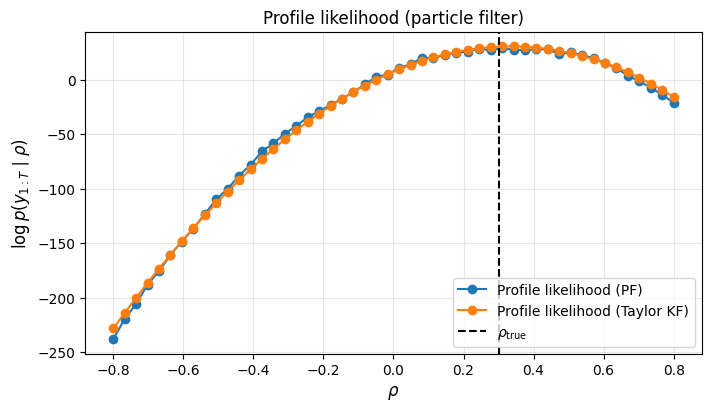

In [49]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(rho_grid, mll_pf, "o-", color="C0", label="Profile likelihood (PF)")
ax.plot(rho_grid, mll_kf, "o-", color="C1", label="Profile likelihood (Taylor KF)")
ax.axvline(rho_true, color="k", linestyle="--", label=r"$\rho_{\mathrm{true}}$")
ax.set_xlabel(r"$\rho$", fontsize=12)
ax.set_ylabel(r"$\log p(y_{1:T} \mid \rho)$", fontsize=12)
ax.set_title("Profile likelihood (particle filter)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Note that if you want to do non-Bayesian things, you can consider the filter-based MLL as a "loss function" and proceed from there with learning dynamical systems from data.


We can also use these likelihood approximations inside other Bayesian inference methods to do posterior inference over unknown parameters.

**Next:** [Part 4 — Filtering + NUTS: pseudomarginal inference](../04_filtering_nuts_pseudomarginal.ipynb)